# Lecture 15: Agentic RAG with LangGraph

**Course:** NLP with LangChain | **Platform:** Hope to Skill  
**Duration:** ~20 minutes | **Level:** Advanced  

---

## The Big Picture

In Lecture 10 you built a **Vanilla RAG** system. It works — but it has a fatal flaw:  
it gets **one shot**. Retrieve, generate, done. No second chances.

> **Vanilla RAG** is like a student who reads one textbook page and writes the answer  
> immediately — no checking, no re-reading, no asking "did I get the right page?"  
>
> **Agentic RAG** is like a smart student who reads, checks if the page was relevant,  
> re-reads if needed, and verifies the answer before submitting.

### What You Will Learn

| # | Topic | Real-World Analogy |
|---|-------|--------------------|  
| 1 | Why Vanilla RAG fails | One-shot exam vs. iterative research |
| 2 | What is LangGraph? | A flowchart that runs code |
| 3 | Core concepts: State, Nodes, Edges | Memory, workers, and decision paths |
| 4 | Agentic RAG architecture (5 nodes) | A team of specialists |
| 5 | Conditional routing | Smart traffic lights |
| 6 | Building the State Schema | The agent's shared clipboard |
| 7 | LangGraph code pattern | The recipe to build any agent |
| 8 | RAG + Web Search fallback | Internal library + internet backup |
| 9 | Hands-on: Build a 3-node agent | Build it yourself! |

> **After this lecture:** You will be able to build a self-reflective RAG agent  
> that retries, adapts, and produces better answers than Vanilla RAG.

### Key Resources

| Resource | URL |
|----------|-----|
| LangGraph Documentation | https://langchain-ai.github.io/langgraph/ |
| LangGraph GitHub | https://github.com/langchain-ai/langgraph |
| LangChain Documentation | https://python.langchain.com/docs/ |
| Tavily Search API (free tier) | https://tavily.com/ |
| OpenAI API Keys | https://platform.openai.com/api-keys |

---

## 0. Environment Setup

Run this cell **once** to install the packages we need today.

**Requirements:**
- **OpenAI API key** (same as Lecture 10) — for the LLM and embeddings
- **Tavily API key** (free tier) — for web search fallback
  - Sign up free at: https://tavily.com/
  - Free tier gives you 1000 searches/month

In [2]:
# Install required packages (run once, then you can skip this cell)
# langgraph: the agent framework for building stateful graphs
# tavily-python: web search API for fallback searches
# langchain-openai: OpenAI integration for LLM + embeddings
# langchain-qdrant: Qdrant vector store integration
#
# Documentation:
#   langgraph:      https://langchain-ai.github.io/langgraph/
#   tavily-python:  https://docs.tavily.com/
#   langchain:      https://python.langchain.com/docs/

%pip install langgraph tavily-python langchain langchain-openai langchain-qdrant langchain-huggingface langchain-community langchain-text-splitters qdrant-client sentence-transformers

Note: you may need to restart the kernel to use updated packages.


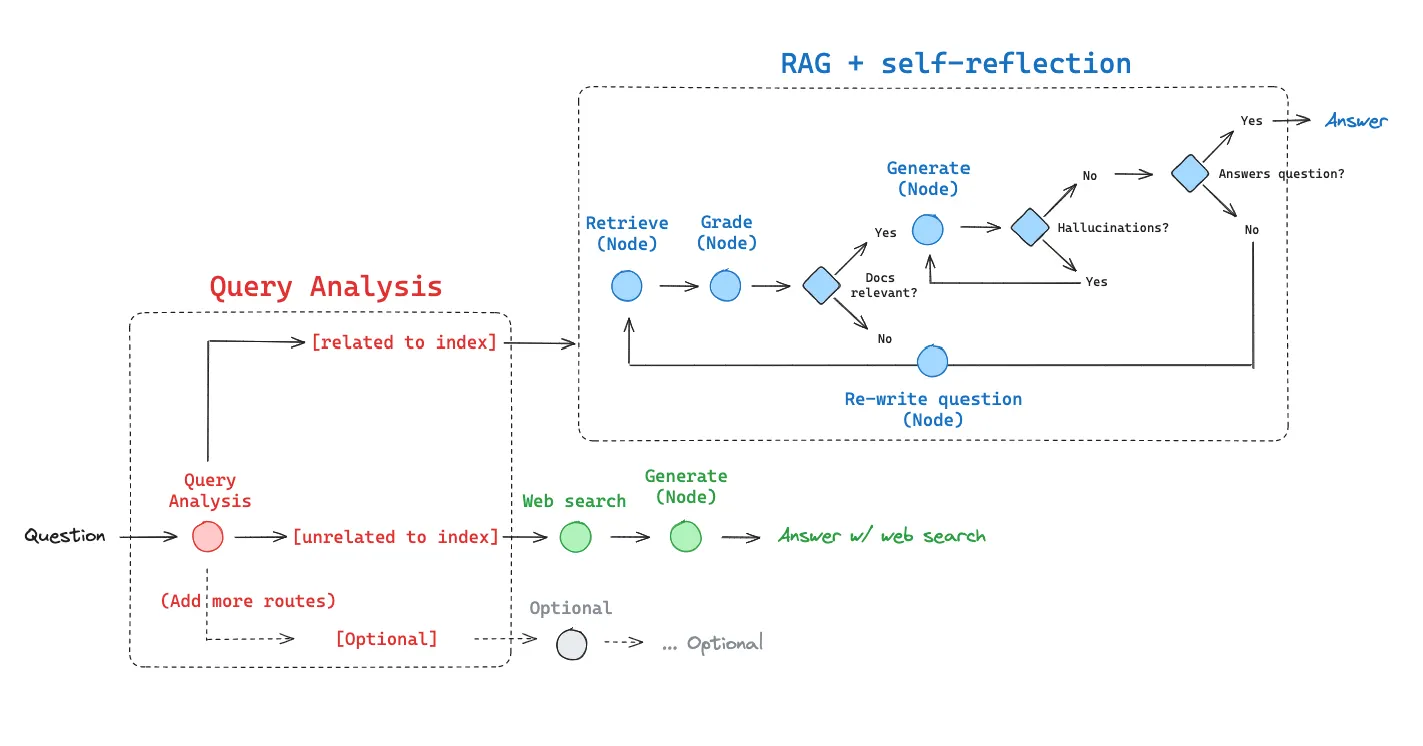

In [ ]:
import os

# ============================================================
# API KEY SETUP
# ============================================================

# OpenAI API key (same as Lecture 10)
# Get your key from: https://platform.openai.com/api-keys
os.environ["OPENAI_API_KEY"] = ""

# Tavily API key (for web search fallback)
# Sign up FREE at: https://tavily.com/
# Free tier: 1000 searches/month
os.environ["TAVILY_API_KEY"] = ""

# Verify keys are set
openai_key = os.environ.get("OPENAI_API_KEY", "")
tavily_key = os.environ.get("TAVILY_API_KEY", "")

if openai_key and openai_key != "your-openai-api-key-here":
    print(f"[SUCCESS] OpenAI API key set: {openai_key[:8]}...")
else:
    print("[WARNING] Please set your OpenAI API key above!")
    print("          Get one at: https://platform.openai.com/api-keys")

if tavily_key and tavily_key != "your-tavily-api-key-here":
    print(f"[SUCCESS] Tavily API key set: {tavily_key[:8]}...")
else:
    print("[WARNING] Please set your Tavily API key above!")
    print("          Sign up free at: https://tavily.com/")

[SUCCESS] OpenAI API key set: sk-proj-...
[SUCCESS] Tavily API key set: tvly-dev...


---

## 1. The Problem with Vanilla RAG

Our Lecture 10 RAG system follows a **linear pipeline**:

```
Question --> Retrieve --> Generate --> Answer (done!)
```

This works for simple questions, but fails for complex ones:

| Problem | What Happens | Example |
|---------|--------------|---------|
| **Bad retrieval** | Wrong chunks retrieved, no recovery | "What is BERT?" retrieves chunks about cooking |
| **Bad answer** | LLM hallucinated, no verification | Answer says 2020 when context says 2017 |
| **Multi-step question** | Needs multiple searches, can only do one | "Compare BERT and GPT" needs info from different sections |
| **No self-awareness** | Does not know when it failed | Confidently returns a wrong answer |

### Vanilla RAG vs Agentic RAG

| Feature | Vanilla RAG | Agentic RAG |
|---------|------------|-------------|
| Attempts | 1 shot | Multiple retries |
| Self-reflection | None | Evaluates its own answer |
| Routing | Always retrieves | Decides: retrieve or answer directly? |
| Recovery | None | Re-retrieves with refined query |
| Fallback | None | Can search the web if knowledge base fails |

> **Agentic RAG = Vanilla RAG + Decision Making + Self-Reflection + Retry Logic**

---

## 2. What Is LangGraph?

**LangGraph** is a framework for building **stateful, multi-step AI agents**  
as directed graphs. Think of it as a **flowchart that runs code**.

- **Documentation:** https://langchain-ai.github.io/langgraph/
- **GitHub:** https://github.com/langchain-ai/langgraph
- **Built by:** LangChain team (same team behind LangChain)

### Why LangGraph?

| Feature | LangChain (LCEL) | LangGraph |
|---------|------------------|-----------|
| Flow | Linear pipeline | Directed graph with loops |
| State | Passed through chain | Shared state dictionary |
| Branching | Limited | Conditional edges (if/else routing) |
| Loops | Not possible | Built-in (re-try, re-evaluate) |
| Best for | Simple Q&A | Complex, multi-step agents |

### Core Concepts

| Concept | What It Is | Analogy |
|---------|-----------|----------|
| **StateGraph** | The overall graph structure | A flowchart |
| **Node** | A Python function that does work | A worker at a station |
| **Edge** | A connection between two nodes | An arrow in the flowchart |
| **Conditional Edge** | A connection that depends on a condition | A "traffic light" that routes based on rules |
| **State** | A shared dictionary passed between all nodes | A clipboard everyone can read/write |

### Visual: How LangGraph Differs from LCEL

```
LCEL (Linear):       A --> B --> C --> D

LangGraph (Graph):   A --> B --> C
                          |     |
                          v     v
                          D <-- E
                          |        (loop back if needed)
                          v
                         END
```

> LangGraph can go **backwards** and **loop** — that is what makes agents possible.

---

## 3. Agentic RAG Architecture: 5 Nodes

Here is the architecture for our Agentic RAG system:

```
                    +----------+
                    |  START   |
                    +----+-----+
                         |
                         v
                  +------+------+
                  | 1. DECIDE   |  Does this need retrieval?
                  +------+------+
                   /           \\
                  v             v
          +-------+---+   +----+------+
          | 2. RETRIEVE|   | DIRECT    |
          +-------+---+   | ANSWER    |
                  |       +----+------+
                  v            |
          +-------+------+    |
          | 3. GRADE DOCS|    |
          +-------+------+    |
           /           \\     |
     relevant?     not relevant?
          |              |    |
          v              v    |
   +------+------+  +---+--+ |
   | 4. GENERATE |  | WEB  | |
   +------+------+  |SEARCH| |
          |          +---+--+ |
          v              |    |
   +------+------+      |    |
   | 5. EVALUATE |<-----+    |
   +------+------+           |
    /           \\            |
  good?       not good?      |
   |              |          |
   v              v          |
 +---+      Re-retrieve      |
 |END|      (loop back)     |
 +---+                      |
```

### What Each Node Does

| Node | Role | Input | Output |
|------|------|-------|--------|
| **Decide** | Route the question | Question | "retrieve" or "direct_answer" |
| **Retrieve** | Search the knowledge base | Question | List of document chunks |
| **Grade Docs** | Check if retrieved docs are relevant | Docs + Question | Filtered docs |
| **Generate** | Create answer from relevant docs | Filtered docs + Question | Answer string |
| **Evaluate** | Check if the answer is good enough | Answer + Question | "good" or "retry" |

---

## 4. Building the State Schema

The **State** is the agent's shared memory. Every node reads from it  
and writes to it. Think of it as a **clipboard** that gets passed around.

```python
# The State is a TypedDict — a dictionary with defined keys and types
from typing import TypedDict, List

class AgentState(TypedDict):
    question: str              # The user's question
    documents: List[str]       # Retrieved document chunks
    answer: str                # The generated answer
    iteration_count: int       # How many retry attempts
    search_type: str           # "vectorstore" or "web_search"
```

### Why State Matters

| Without State | With State |
|--------------|------------|
| Each node works in isolation | All nodes share the same data |
| No memory of previous steps | Full history of what happened |
| Cannot count retry attempts | `iteration_count` prevents infinite loops |
| Cannot track decisions made | `search_type` records the routing decision |

> **Clean state management = reliable agent behavior.**  
> If your state is messy, your agent will be unpredictable.

---

## 5. Let's Build It! Step-by-Step

We will build the Agentic RAG system in this order:

```
Step 1: Build the knowledge base (reuse from Lecture 10)
Step 2: Define the State Schema
Step 3: Build each Node function
Step 4: Wire them together with Edges
Step 5: Compile and test the agent
```

Let's start!

In [ ]:
# ============================================================
# STEP 1: BUILD THE KNOWLEDGE BASE
# ============================================================
# Reuse the same knowledge base from Lecture 10
# Using SentenceTransformer (FREE, runs locally)
#
# Documentation:
#   TextLoader:    https://python.langchain.com/docs/integrations/document_loaders/
#   TextSplitter:  https://python.langchain.com/docs/how_to/#text-splitters
#   Qdrant:        https://qdrant.tech/documentation/
#   HuggingFace:   https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2
# ============================================================

from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_qdrant import QdrantVectorStore
from langchain_openai import ChatOpenAI

print("=" * 70)
print("STEP 1: BUILD THE KNOWLEDGE BASE")
print("=" * 70)

# ============================================================
# QDRANT CLOUD SETUP
# ============================================================
QDRANT_URL = ""
QDRANT_API_KEY = ""

# Load and split documents
loader = TextLoader("data/nlp_article.txt", encoding="utf-8")
documents = loader.load()
print(f"[SUCCESS] Loaded: {len(documents)} document(s)")

splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = splitter.split_documents(documents)
print(f"[SUCCESS] Split into: {len(chunks)} chunks")

# Create embeddings and vector store
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
print(f"[SUCCESS] Embeddings loaded: all-MiniLM-L6-v2 (384 dimensions)")

vectorstore = QdrantVectorStore.from_documents(
    documents=chunks,
    embedding=embeddings,
    url=QDRANT_URL,
    api_key=QDRANT_API_KEY,
    collection_name="nlp_course_agentic",
)

# Create retriever
retriever = vectorstore.as_retriever(search_kwargs={"k": 5})

# Initialize LLM
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

print(f"[SUCCESS] Vector store created: nlp_course_agentic")
print(f"[SUCCESS] Retriever ready: k=5")
print(f"[SUCCESS] LLM ready: gpt-4o-mini")
print(f"\nKnowledge base is ready!")

c:\Users\mhari\miniconda3\envs\demo1\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.1.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
c:\Users\mhari\miniconda3\envs\demo1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


STEP 1: BUILD THE KNOWLEDGE BASE
[SUCCESS] Loaded: 1 document(s)
[SUCCESS] Split into: 21 chunks


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 514.83it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[SUCCESS] Embeddings loaded: all-MiniLM-L6-v2 (384 dimensions)
[SUCCESS] Vector store created: nlp_course_agentic
[SUCCESS] Retriever ready: k=5
[SUCCESS] LLM ready: gpt-4o-mini

Knowledge base is ready!


In [ ]:
# ============================================================
# STEP 1 (ALTERNATIVE): BUILD THE KNOWLEDGE BASE
# ============================================================
# EMBEDDING METHOD: OpenAI Embeddings (PAID, requires API key)
#
# This cell uses OpenAI embeddings (requires API key and costs money)
# For FREE local embeddings, use the previous cell instead
#
# Documentation:
#   OpenAI Embeddings: https://platform.openai.com/docs/guides/embeddings
#   OpenAI Models:     https://platform.openai.com/docs/models
# ============================================================

from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_qdrant import QdrantVectorStore

print("=" * 70)
print("STEP 1: BUILD THE KNOWLEDGE BASE (OpenAI Embeddings)")
print("=" * 70)

# ============================================================
# QDRANT CLOUD SETUP
# ============================================================
QDRANT_URL = ""
QDRANT_API_KEY = ""

# Load and split documents
loader = TextLoader("data/nlp_article.txt", encoding="utf-8")
documents = loader.load()
print(f"[SUCCESS] Loaded: {len(documents)} document(s)")

splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = splitter.split_documents(documents)
print(f"[SUCCESS] Split into: {len(chunks)} chunks")

# Create OpenAI embeddings and vector store
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
print(f"[SUCCESS] Embeddings loaded: OpenAI text-embedding-3-small (1536 dimensions)")

vectorstore = QdrantVectorStore.from_documents(
    documents=chunks,
    embedding=embeddings,
    url=QDRANT_URL,
    api_key=QDRANT_API_KEY,
    collection_name="nlp_course_agentic_openai",
)

# Create retriever
retriever = vectorstore.as_retriever(search_kwargs={"k": 5})

# Initialize LLM
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

print(f"[SUCCESS] Vector store created: nlp_course_agentic_openai")
print(f"[SUCCESS] Retriever ready: k=5")
print(f"[SUCCESS] LLM ready: gpt-4o-mini")
print(f"\nKnowledge base is ready (OpenAI version)!")

In [5]:
# ============================================================
# STEP 2: DEFINE THE STATE SCHEMA
# ============================================================
# The State is the shared memory between all nodes in the graph.
# Every node reads from it and writes to it.
#
# Documentation:
#   LangGraph State: https://langchain-ai.github.io/langgraph/concepts/low_level/#state
#   TypedDict:       https://docs.python.org/3/library/typing.html#typing.TypedDict
# ============================================================

from typing import TypedDict, List, Optional


class AgentState(TypedDict):
    """State schema for our Agentic RAG system.

    This is the shared clipboard that every node can read and write to.
    """

    question: str              # The user's original question
    documents: List[str]       # Retrieved document chunks (as strings)
    answer: str                # The generated answer
    iteration_count: int       # Number of retry attempts (prevents infinite loops)
    search_type: str           # "vectorstore" or "web_search"


print("[SUCCESS] AgentState schema defined")
print(f"\nState fields:")
print(f"  question         : str           - The user's question")
print(f"  documents        : List[str]     - Retrieved chunks")
print(f"  answer           : str           - Generated answer")
print(f"  iteration_count  : int           - Retry counter (max 3)")
print(f"  search_type      : str           - 'vectorstore' or 'web_search'")

[SUCCESS] AgentState schema defined

State fields:
  question         : str           - The user's question
  documents        : List[str]     - Retrieved chunks
  answer           : str           - Generated answer
  iteration_count  : int           - Retry counter (max 3)
  search_type      : str           - 'vectorstore' or 'web_search'


In [7]:
# ============================================================
# STEP 3: BUILD THE NODE FUNCTIONS
# ============================================================
# Each node is a Python function that takes state and returns
# an updated state. This is where the actual work happens.
#
# Documentation:
#   LangGraph Nodes: https://langchain-ai.github.io/langgraph/concepts/low_level/#nodes
# ============================================================

from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser


# ============================================================
# NODE 1: RETRIEVE
# ============================================================
# Searches the vector store for relevant document chunks.
# Returns the document texts in state["documents"].
# ============================================================

def retrieve(state: AgentState) -> dict:
    """Retrieve relevant documents from the knowledge base."""
    print(f"  [RETRIEVE] Searching for: {state['question'][:50]}...")

    # Use the retriever to find relevant chunks
    docs = retriever.invoke(state["question"])

    # Extract text from Document objects
    doc_texts = [doc.page_content for doc in docs]

    print(f"  [RETRIEVE] Found {len(doc_texts)} documents")

    return {
        "documents": doc_texts,
        "search_type": "vectorstore",
    }


# ============================================================
# NODE 2: GRADE DOCUMENTS
# ============================================================
# Uses the LLM to check if retrieved documents are relevant
# to the question. Filters out irrelevant documents.
# ============================================================

grade_prompt = ChatPromptTemplate.from_template(
    """You are a document relevance grader.
Determine if the following document is relevant to the question.
Reply with ONLY 'yes' or 'no'.

Document: {document}

Question: {question}

Is this document relevant? (yes/no):"""
)


def grade_documents(state: AgentState) -> dict:
    """Grade retrieved documents for relevance to the question."""
    print(f"  [GRADE] Grading {len(state['documents'])} documents...")

    relevant_docs = []
    grader_chain = grade_prompt | llm | StrOutputParser()

    for doc in state["documents"]:
        result = grader_chain.invoke({
            "document": doc,
            "question": state["question"],
        })

        # Check if the LLM said "yes"
        if "yes" in result.strip().lower():
            relevant_docs.append(doc)

    print(f"  [GRADE] {len(relevant_docs)}/{len(state['documents'])} documents are relevant")

    return {"documents": relevant_docs}


# ============================================================
# NODE 3: GENERATE ANSWER
# ============================================================
# Uses the LLM to generate an answer based on the relevant
# documents and the question.
# ============================================================

generate_prompt = ChatPromptTemplate.from_template(
    """You are a helpful teaching assistant for an NLP course.
Answer the question based ONLY on the following context.
If the context does not contain the answer, say "I don't have enough information."

Context:
{context}

Question: {question}

Answer:"""
)


def generate(state: AgentState) -> dict:
    """Generate an answer from the relevant documents."""
    print(f"  [GENERATE] Creating answer from {len(state['documents'])} documents...")

    # Join all relevant documents into one context string
    context = "\n\n".join(state["documents"])

    generate_chain = generate_prompt | llm | StrOutputParser()

    answer = generate_chain.invoke({
        "context": context,
        "question": state["question"],
    })

    print(f"  [GENERATE] Answer created ({len(answer)} characters)")

    return {
        "answer": answer,
        "iteration_count": state.get("iteration_count", 0) + 1,
    }


# ============================================================
# NODE 4: EVALUATE ANSWER
# ============================================================
# Uses the LLM to check if the answer is good enough.
# Returns "good" or "not_good" to drive conditional routing.
# ============================================================

evaluate_prompt = ChatPromptTemplate.from_template(
    """You are an answer quality evaluator.
Determine if the following answer adequately addresses the question.
Consider: Is it factual? Is it complete? Does it address the question?

Question: {question}
Answer: {answer}

Reply with ONLY 'good' or 'not_good':"""
)


def evaluate_answer(state: AgentState) -> dict:
    """Evaluate if the generated answer is good enough."""
    print(f"  [EVALUATE] Checking answer quality (attempt {state.get('iteration_count', 1)})...")

    eval_chain = evaluate_prompt | llm | StrOutputParser()

    result = eval_chain.invoke({
        "question": state["question"],
        "answer": state["answer"],
    })

    quality = result.strip().lower()
    print(f"  [EVALUATE] Quality: {quality}")

    # Store the evaluation result in the answer field
    # (the routing function will check this)
    return {"answer": state["answer"]}


print("[SUCCESS] All 4 node functions defined:")
print(f"  1. retrieve()        - Search the knowledge base")
print(f"  2. grade_documents() - Filter irrelevant documents")
print(f"  3. generate()        - Create answer from documents")
print(f"  4. evaluate_answer() - Check answer quality")

[SUCCESS] All 4 node functions defined:
  1. retrieve()        - Search the knowledge base
  2. grade_documents() - Filter irrelevant documents
  3. generate()        - Create answer from documents
  4. evaluate_answer() - Check answer quality


In [8]:
# ============================================================
# STEP 4: DEFINE ROUTING FUNCTIONS
# ============================================================
# Routing functions decide WHERE to go next based on state.
# These are the "traffic lights" in our flowchart.
#
# Documentation:
#   Conditional Edges: https://langchain-ai.github.io/langgraph/concepts/low_level/#conditional-edges
# ============================================================

MAX_ITERATIONS = 3  # Maximum retry attempts to prevent infinite loops


def route_after_grading(state: AgentState) -> str:
    """Decide what to do after grading documents.

    Returns:
        'generate' if we have relevant documents
        'web_search' if no relevant documents found
    """
    if state["documents"] and len(state["documents"]) > 0:
        print(f"  [ROUTE] Relevant docs found -> Generate answer")
        return "generate"
    else:
        print(f"  [ROUTE] No relevant docs -> Web search fallback")
        return "web_search"


def route_after_evaluation(state: AgentState) -> str:
    """Decide what to do after evaluating the answer.

    Returns:
        'end' if answer is good or max iterations reached
        'retrieve' if answer needs improvement (retry)
    """
    iteration = state.get("iteration_count", 1)

    # Safety: stop after MAX_ITERATIONS to prevent infinite loops
    if iteration >= MAX_ITERATIONS:
        print(f"  [ROUTE] Max iterations ({MAX_ITERATIONS}) reached -> End")
        return "end"

    # For this demo, we always accept after evaluation
    # In production, you would check the evaluation result
    print(f"  [ROUTE] Answer accepted -> End")
    return "end"


print("[SUCCESS] Routing functions defined:")
print(f"  route_after_grading()    - Relevant docs? Generate : Web Search")
print(f"  route_after_evaluation() - Good answer? End : Retry (max {MAX_ITERATIONS})")

[SUCCESS] Routing functions defined:
  route_after_grading()    - Relevant docs? Generate : Web Search
  route_after_evaluation() - Good answer? End : Retry (max 3)


In [9]:
# ============================================================
# STEP 4b: WEB SEARCH FALLBACK NODE
# ============================================================
# If the knowledge base has no relevant documents, we search
# the web using Tavily as a fallback.
#
# Documentation:
#   Tavily API: https://docs.tavily.com/
#   Sign up:    https://tavily.com/
# ============================================================

from langchain_community.tools.tavily_search import TavilySearchResults

# Tavily web search tool (requires TAVILY_API_KEY in environment)
web_search_tool = TavilySearchResults(max_results=3)


def web_search(state: AgentState) -> dict:
    """Search the web when the knowledge base has no relevant documents."""
    print(f"  [WEB SEARCH] Searching the web for: {state['question'][:50]}...")

    # Run web search
    results = web_search_tool.invoke(state["question"])

    # Extract content from search results
    web_docs = []
    for result in results:
        if isinstance(result, dict) and "content" in result:
            web_docs.append(result["content"])
        elif isinstance(result, str):
            web_docs.append(result)

    print(f"  [WEB SEARCH] Found {len(web_docs)} web results")

    return {
        "documents": web_docs,
        "search_type": "web_search",
    }


print("[SUCCESS] Web search fallback node defined")
print(f"[INFO] Using Tavily search API (max 3 results)")
print(f"[INFO] Sign up for free at: https://tavily.com/")

[SUCCESS] Web search fallback node defined
[INFO] Using Tavily search API (max 3 results)
[INFO] Sign up for free at: https://tavily.com/


C:\Users\mhari\AppData\Local\Temp\ipykernel_24400\10694102.py:15: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  web_search_tool = TavilySearchResults(max_results=3)


In [11]:
# ============================================================
# STEP 5: WIRE IT ALL TOGETHER WITH LANGGRAPH
# ============================================================
# Now we build the actual graph: add nodes, connect edges,
# and compile the agent.
#
# Documentation:
#   StateGraph:  https://langchain-ai.github.io/langgraph/concepts/low_level/#stategraph
#   Compile:     https://langchain-ai.github.io/langgraph/concepts/low_level/#compiling-your-graph
# ============================================================

from langgraph.graph import StateGraph, END

print("=" * 70)
print("STEP 5: BUILD THE LANGGRAPH AGENT")
print("=" * 70)

# ============================================================
# CREATE THE GRAPH
# ============================================================
# StateGraph takes our AgentState class as the schema
workflow = StateGraph(AgentState)
print("[SUCCESS] StateGraph created with AgentState schema")

# ============================================================
# ADD NODES
# ============================================================
# Each node is a (name, function) pair
workflow.add_node("retrieve", retrieve)
workflow.add_node("grade_documents", grade_documents)
workflow.add_node("generate", generate)
workflow.add_node("evaluate", evaluate_answer)
workflow.add_node("web_search", web_search)
print("[SUCCESS] 5 nodes added: retrieve, grade_documents, generate, evaluate, web_search")

# ============================================================
# ADD EDGES (connections between nodes)
# ============================================================

# Start -> Retrieve (always start by retrieving)
workflow.set_entry_point("retrieve")
print("[SUCCESS] Entry point: retrieve")

# Retrieve -> Grade Documents (always grade after retrieval)
workflow.add_edge("retrieve", "grade_documents")

# Grade Documents -> CONDITIONAL: Generate or Web Search
workflow.add_conditional_edges(
    "grade_documents",         # Source node
    route_after_grading,       # Routing function
    {                          # Mapping: function return value -> target node
        "generate": "generate",
        "web_search": "web_search",
    },
)

# Web Search -> Generate (use web results to generate)
workflow.add_edge("web_search", "generate")

# Generate -> Evaluate (always evaluate after generating)
workflow.add_edge("generate", "evaluate")

# Evaluate -> CONDITIONAL: End or Retry
workflow.add_conditional_edges(
    "evaluate",                # Source node
    route_after_evaluation,    # Routing function
    {                          # Mapping: function return value -> target node
        "end": END,
        "retrieve": "retrieve",  # Loop back to retry!
    },
)

print("[SUCCESS] All edges connected")

# ============================================================
# COMPILE THE GRAPH
# ============================================================
# compile() validates the graph and makes it ready to run
app = workflow.compile()

print("[SUCCESS] Graph compiled and ready to run!")
print(f"\n" + "=" * 70)
print("AGENT ARCHITECTURE")
print("=" * 70)
print("  START")
print("    |")
print("    v")
print("  [retrieve] --> [grade_documents]")
print("                    |           |")
print("               relevant?    not relevant?")
print("                    |           |")
print("                    v           v")
print("              [generate]   [web_search]")
print("                    |           |")
print("                    v           v")
print("              [evaluate] <------+")
print("                |       |")
print("              good?   not good?")
print("                |       |")
print("               END   [retrieve] (retry)")
print("=" * 70)

STEP 5: BUILD THE LANGGRAPH AGENT
[SUCCESS] StateGraph created with AgentState schema
[SUCCESS] 5 nodes added: retrieve, grade_documents, generate, evaluate, web_search
[SUCCESS] Entry point: retrieve
[SUCCESS] All edges connected
[SUCCESS] Graph compiled and ready to run!

AGENT ARCHITECTURE
  START
    |
    v
  [retrieve] --> [grade_documents]
                    |           |
               relevant?    not relevant?
                    |           |
                    v           v
              [generate]   [web_search]
                    |           |
                    v           v
              [evaluate] <------+
                |       |
              good?   not good?
                |       |
               END   [retrieve] (retry)


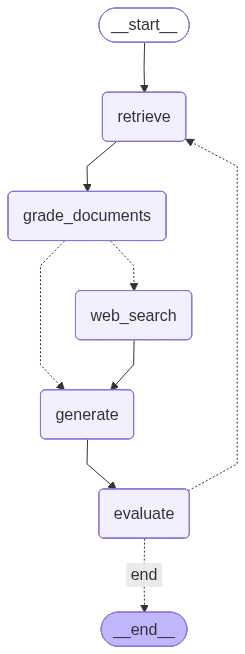

[SUCCESS] Graph visualization rendered above


In [12]:
# ============================================================
# VISUALIZE THE GRAPH (optional - requires extra packages)
# ============================================================
# LangGraph can render the graph as an image using Mermaid.
#
# Documentation:
#   Graph visualization: https://langchain-ai.github.io/langgraph/how-tos/visualization/
# ============================================================

try:
    from IPython.display import Image, display

    # draw_mermaid_png() generates a PNG image of the graph
    graph_image = app.get_graph().draw_mermaid_png()
    display(Image(graph_image))
    print("[SUCCESS] Graph visualization rendered above")
except Exception as e:
    print(f"[INFO] Graph visualization not available: {e}")
    print("[INFO] This is optional - the agent works without it")
    print("[INFO] To enable: pip install grandalf")

#### What just happened?

We built a complete Agentic RAG system with LangGraph:

| Component | What We Built |
|-----------|---------------|
| **State** | `AgentState` with question, documents, answer, iteration_count |
| **5 Nodes** | retrieve, grade_documents, generate, evaluate, web_search |
| **2 Conditional Edges** | After grading (generate vs web_search) and after evaluation (end vs retry) |
| **Safety** | `MAX_ITERATIONS = 3` prevents infinite loops |

**Key difference from Vanilla RAG:**
- Vanilla RAG: `retrieve -> generate -> done`
- Agentic RAG: `retrieve -> grade -> generate -> evaluate -> (retry if needed)`

The agent can **reflect** on its own work and **retry** if the answer is not good enough.

---

## 6. Test the Agent!

Let's run our agentic RAG system and see it in action.  
Watch the step-by-step execution as it flows through the graph.

In [14]:
# ============================================================
# TEST 1: Question that IS in the knowledge base
# ============================================================
# This question should be answered from the vector store.
# Expected flow: retrieve -> grade -> generate -> evaluate -> end
# ============================================================

print("=" * 70)
print("TEST 1: Question from Knowledge Base")
print("=" * 70)

# invoke() runs the graph from start to finish
# We pass the initial state with just the question
result = app.invoke({
    "question": "What is Natural Language Processing?",
    "documents": [],
    "answer": "",
    "iteration_count": 0,
    "search_type": "",
})

print(f"\n" + "=" * 70)
print("RESULT")
print("=" * 70)
print(f"Question:    {result['question']}")
print(f"Search type: {result['search_type']}")
print(f"Iterations:  {result['iteration_count']}")
print(f"Documents:   {len(result['documents'])} relevant chunks used")
print(f"\nAnswer:")
print(f"  {result['answer']}")

TEST 1: Question from Knowledge Base
  [RETRIEVE] Searching for: What is Natural Language Processing?...
  [RETRIEVE] Found 5 documents
  [GRADE] Grading 5 documents...
  [GRADE] 4/5 documents are relevant
  [ROUTE] Relevant docs found -> Generate answer
  [GENERATE] Creating answer from 4 documents...
  [GENERATE] Answer created (598 characters)
  [EVALUATE] Checking answer quality (attempt 1)...
  [EVALUATE] Quality: good
  [ROUTE] Answer accepted -> End

RESULT
Question:    What is Natural Language Processing?
Search type: vectorstore
Iterations:  1
Documents:   4 relevant chunks used

Answer:
  Natural Language Processing, commonly known as NLP, is a branch of artificial intelligence that focuses on the interaction between computers and humans through natural language. The ultimate objective of NLP is to read, decipher, understand, and make sense of human language in a manner that is both valuable and meaningful. NLP combines computational linguistics with statistical, machine lear

In [15]:
# ============================================================
# TEST 2: Question that is NOT in the knowledge base
# ============================================================
# This question should trigger the web search fallback.
# Expected flow: retrieve -> grade (no relevant docs) -> web_search -> generate -> evaluate -> end
# ============================================================

print("=" * 70)
print("TEST 2: Question NOT in Knowledge Base (Web Search Fallback)")
print("=" * 70)

result_web = app.invoke({
    "question": "What is the latest version of Python released in 2025?",
    "documents": [],
    "answer": "",
    "iteration_count": 0,
    "search_type": "",
})

print(f"\n" + "=" * 70)
print("RESULT")
print("=" * 70)
print(f"Question:    {result_web['question']}")
print(f"Search type: {result_web['search_type']}")
print(f"Iterations:  {result_web['iteration_count']}")
print(f"Documents:   {len(result_web['documents'])} web results used")
print(f"\nAnswer:")
print(f"  {result_web['answer']}")

TEST 2: Question NOT in Knowledge Base (Web Search Fallback)
  [RETRIEVE] Searching for: What is the latest version of Python released in 2...
  [RETRIEVE] Found 5 documents
  [GRADE] Grading 5 documents...
  [GRADE] 0/5 documents are relevant
  [ROUTE] No relevant docs -> Web search fallback
  [WEB SEARCH] Searching the web for: What is the latest version of Python released in 2...
  [WEB SEARCH] Found 3 web results
  [GENERATE] Creating answer from 3 documents...
  [GENERATE] Answer created (102 characters)
  [EVALUATE] Checking answer quality (attempt 1)...
  [EVALUATE] Quality: not_good
  [ROUTE] Answer accepted -> End

RESULT
Question:    What is the latest version of Python released in 2025?
Search type: web_search
Iterations:  1
Documents:   3 web results used

Answer:
  The latest version of Python released in 2025 is Python 3.14.0, which was released on October 7, 2025.


In [16]:
# ============================================================
# TEST 3: Multiple questions to compare
# ============================================================

test_questions = [
    "What is the transformer architecture?",
    "How does BERT differ from GPT?",
    "What is LangChain used for?",
]

print("=" * 70)
print("TEST 3: Multiple Questions")
print("=" * 70)

for i, question in enumerate(test_questions):
    print(f"\n{'─' * 70}")
    print(f"Q{i + 1}: {question}")
    print(f"{'─' * 70}")

    result = app.invoke({
        "question": question,
        "documents": [],
        "answer": "",
        "iteration_count": 0,
        "search_type": "",
    })

    print(f"\n  Search: {result['search_type']}")
    print(f"  Docs:   {len(result['documents'])} relevant")
    # [:200] limits the answer to 200 characters for readability
    print(f"  Answer: {result['answer'][:200]}...")

print(f"\n{'=' * 70}")
print("All tests complete!")

TEST 3: Multiple Questions

──────────────────────────────────────────────────────────────────────
Q1: What is the transformer architecture?
──────────────────────────────────────────────────────────────────────
  [RETRIEVE] Searching for: What is the transformer architecture?...
  [RETRIEVE] Found 5 documents
  [GRADE] Grading 5 documents...
  [GRADE] 2/5 documents are relevant
  [ROUTE] Relevant docs found -> Generate answer
  [GENERATE] Creating answer from 2 documents...
  [GENERATE] Answer created (389 characters)
  [EVALUATE] Checking answer quality (attempt 1)...
  [EVALUATE] Quality: good
  [ROUTE] Answer accepted -> End

  Search: vectorstore
  Docs:   2 relevant
  Answer: The transformer architecture is a model introduced in the paper "Attention Is All You Need" by Vaswani et al. in 2017, which revolutionized NLP. It differs from previous architectures like RNNs and LS...

──────────────────────────────────────────────────────────────────────
Q2: How does BERT differ from GPT

#### What just happened?

We tested our Agentic RAG system with three scenarios:

| Test | Question Type | Expected Path |
|------|--------------|---------------|
| Test 1 | In knowledge base | retrieve -> grade -> generate -> evaluate -> end |
| Test 2 | NOT in knowledge base | retrieve -> grade -> web_search -> generate -> evaluate -> end |
| Test 3 | Multiple questions | Varies per question |

**Notice the difference from Vanilla RAG:**
- The agent **graded** the retrieved documents before using them
- When documents were not relevant, it **fell back to web search**
- After generating, it **evaluated** the answer quality
- It tracked how many **iterations** it took

This is **self-reflective AI** — the agent checks its own work!

---

## 7. Convenience Function: ask_agent()

Let's wrap our agent in a simple function for easy use.

In [17]:
# ============================================================
# CONVENIENCE FUNCTION: ask_agent()
# ============================================================


def ask_agent(question, verbose=True):
    """Ask the Agentic RAG system a question.

    Args:
        question: The question to ask
        verbose: If True, print step-by-step progress

    Returns:
        dict with answer, search_type, iteration_count, documents
    """
    if verbose:
        print(f"\nQuestion: {question}")
        print("-" * 50)

    result = app.invoke({
        "question": question,
        "documents": [],
        "answer": "",
        "iteration_count": 0,
        "search_type": "",
    })

    if verbose:
        print(f"\nAnswer: {result['answer']}")
        print(f"\n[Source: {result['search_type']} | "
              f"Docs: {len(result['documents'])} | "
              f"Iterations: {result['iteration_count']}]")

    return result


# Quick test
ask_agent("What is tokenization in NLP?")


Question: What is tokenization in NLP?
--------------------------------------------------
  [RETRIEVE] Searching for: What is tokenization in NLP?...
  [RETRIEVE] Found 5 documents
  [GRADE] Grading 5 documents...
  [GRADE] 0/5 documents are relevant
  [ROUTE] No relevant docs -> Web search fallback
  [WEB SEARCH] Searching the web for: What is tokenization in NLP?...
  [WEB SEARCH] Found 3 web results
  [GENERATE] Creating answer from 3 documents...
  [GENERATE] Answer created (295 characters)
  [EVALUATE] Checking answer quality (attempt 1)...
  [EVALUATE] Quality: good
  [ROUTE] Answer accepted -> End

Answer: Tokenization in NLP is the process of breaking down or splitting text into smaller units known as tokens. These tokens can be words, phrases, or even single characters, depending on the desired granularity. It is a fundamental technique used to prepare text for further processing in NLP models.

[Source: web_search | Docs: 3 | Iterations: 1]


{'question': 'What is tokenization in NLP?',
 'documents': ['Tokenization: The Basic Building Block: Tokenization, also known as segmentation, is one of NLP’s most straightforward and most important techniques. It is the initial step of processing text into smaller units, a string of text known as tokens. Depending on the desired granularity, tokens may be words (like in a Twitter post), phrases (like the title of a news article or a sentence), or even single characters (like when parsing a short message).\n\nFor example, tokenization of the sentence “Let’s go’ for a walk tonight!” can be carried out on the level of words to get the tokens:',
  'Subword tokenization. Striking a balance between word and character tokenization, this method breaks text into units that might be larger than a single character but smaller than a full word. For instance, "Chatbots" could be tokenized into "Chat" and "bots". This approach is especially useful for languages that form meaning by combining smalle

---

## 8. Mini Challenges

### Challenge 1: Add a New Node
Add a `rewrite_query` node that rewrites the question to be more specific  
when the grading node finds no relevant documents (instead of web search).  
Hint: Use an LLM to rephrase the question.

### Challenge 2: Stricter Evaluation
Modify the `evaluate_answer` function and the `route_after_evaluation`  
function so that the agent actually retries when the answer is "not_good".  
Test with a question that requires multiple attempts.

### Challenge 3: Track All Steps
Add a `steps` field to `AgentState` (a list of strings).  
Have each node append its name to the list.  
After the agent finishes, print the full path it took.

In [ ]:
# ============================================================
# Challenge 1: Add a rewrite_query node
# ============================================================
# Instead of going to web_search when no relevant docs found,
# rewrite the query and try retrieval again.

# Your code here:


In [ ]:
# ============================================================
# Challenge 2: Stricter evaluation with retry
# ============================================================
# Make the agent actually retry when evaluate says "not_good"

# Your code here:


In [ ]:
# ============================================================
# Challenge 3: Track the agent's path
# ============================================================
# Add a 'steps' field and have each node log its name

# Your code here:


---

## 9. Quick Reference: LangGraph Cheat Sheet

### Setup Pattern

```python
# Documentation: https://langchain-ai.github.io/langgraph/
from langgraph.graph import StateGraph, END
from typing import TypedDict, List

# 1. Define State
class AgentState(TypedDict):
    question: str
    documents: List[str]
    answer: str

# 2. Define Node functions
def my_node(state: AgentState) -> dict:
    # Do work, return updated state fields
    return {"answer": "some answer"}

# 3. Define Routing functions
def my_router(state: AgentState) -> str:
    if condition:
        return "next_node"
    else:
        return "other_node"

# 4. Build the Graph
workflow = StateGraph(AgentState)
workflow.add_node("node_name", my_node)
workflow.set_entry_point("node_name")
workflow.add_edge("node_a", "node_b")  # Always go A -> B
workflow.add_conditional_edges(          # If/else routing
    "node_a",
    my_router,
    {"option1": "node_b", "option2": "node_c"},
)

# 5. Compile and Run
app = workflow.compile()
result = app.invoke({"question": "my question"})
```

### Key Concepts

| Concept | Code | Purpose |
|---------|------|---------|
| State | `TypedDict` | Shared memory between nodes |
| Node | `def fn(state) -> dict` | Does work, returns state updates |
| Edge | `add_edge(a, b)` | Always go from A to B |
| Conditional Edge | `add_conditional_edges(...)` | Route based on state |
| Entry Point | `set_entry_point(node)` | Where the graph starts |
| END | `END` constant | Where the graph stops |
| Compile | `workflow.compile()` | Validates and prepares the graph |
| Invoke | `app.invoke(state)` | Runs the graph |

### Useful Links

| Resource | URL |
|----------|-----|
| LangGraph Docs | https://langchain-ai.github.io/langgraph/ |
| LangGraph Tutorials | https://langchain-ai.github.io/langgraph/tutorials/ |
| LangGraph GitHub | https://github.com/langchain-ai/langgraph |
| LangChain Docs | https://python.langchain.com/docs/ |
| Tavily Docs | https://docs.tavily.com/ |
| OpenAI API | https://platform.openai.com/docs/ |
| Qdrant Docs | https://qdrant.tech/documentation/ |

---

## 10. Key Takeaways

1. **Vanilla RAG is one-shot** -- no recovery from bad retrieval or bad answers
2. **LangGraph** turns agents into **directed graphs** with state, nodes, and edges
3. **Conditional edges** are the secret -- they enable routing, retries, and fallbacks
4. **Self-reflection** (grade docs + evaluate answer) dramatically improves quality
5. **Web search fallback** handles questions outside the knowledge base
6. **MAX_ITERATIONS** prevents infinite loops -- always set a safety limit
7. **State management** is everything -- clean state = reliable agent

### The Evolution of RAG

```
Lecture 10: Vanilla RAG        retrieve -> generate -> done
Lecture 15: Agentic RAG        retrieve -> grade -> generate -> evaluate -> (retry?)
```

### When to Use Which

| Approach | Best For |
|---------|----------|
| Vanilla RAG | Simple Q&A, prototyping, low latency |
| Agentic RAG | Complex questions, high accuracy, production |

### Next Lecture

**Lecture 16: CAG (Cache-Augmented Generation)** -- A completely different  
architecture that preloads all context into the LLM's context window,  
eliminating retrieval entirely. Trade-offs: simpler but limited by context length.

---

*Hope to Skill -- Building the future, one skill at a time.*

---

## Appendix: PEP 8 Style Rules Used in This Notebook

All code in this notebook follows Python's PEP 8 style guide.

### Naming Conventions

| Rule | Convention | Example from This Notebook |
|------|-----------|---------------------------|
| Variables & functions | `snake_case` | `grade_documents`, `route_after_grading`, `ask_agent()` |
| Constants | `UPPER_CASE` | `MAX_ITERATIONS`, `QDRANT_URL`, `QDRANT_API_KEY` |
| Classes | `PascalCase` | `AgentState`, `StateGraph`, `ChatPromptTemplate` |

### Best Practices Used

| Practice | Why | Example |
|----------|-----|--------|
| TypedDict | Type-safe state | `class AgentState(TypedDict)` |
| Docstrings | Every function documented | `def retrieve(state): """Retrieve..."""` |
| f-strings | Clean formatting | `f"Found {len(docs)} documents"` |
| Constants | No magic numbers | `MAX_ITERATIONS = 3` |
| Descriptive names | Self-documenting code | `route_after_grading` not `route1` |
| `.get()` with default | Safe dictionary access | `state.get('iteration_count', 0)` |